<a href="https://colab.research.google.com/github/rociobelen-21/alura-cursos-challenge3-data-science-LATAM/blob/main/TelecomX_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
from google.colab  import files
uploaded = files.upload()

Saving TelecomX_tratado.csv (1).csv to TelecomX_tratado.csv (1).csv


In [5]:
!ls

 sample_data  'TelecomX_tratado.csv (1).csv'


# Extracción

In [6]:
import pandas as pd
import numpy as np

In [7]:
df = pd.read_csv("TelecomX_tratado.csv (1).csv")

In [8]:
df.head()

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,Contract,PaperlessBilling,PaymentMethod,...,TotalCharges,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,PhoneService,MultipleLines
0,0002-ORFBO,No,Female,0,Yes,Yes,9,One year,Yes,Mailed check,...,593.30,DSL,No,Yes,No,Yes,Yes,No,Yes,No
1,0003-MKNFE,No,Male,0,No,No,9,Month-to-month,No,Mailed check,...,542.40,DSL,No,No,No,No,No,Yes,Yes,Yes
2,0004-TLHLJ,Yes,Male,0,No,No,4,Month-to-month,Yes,Electronic check,...,280.85,Fiber optic,No,No,Yes,No,No,No,Yes,No
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Month-to-month,Yes,Electronic check,...,1237.85,Fiber optic,No,Yes,Yes,No,Yes,Yes,Yes,No
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Month-to-month,Yes,Mailed check,...,267.40,Fiber optic,No,No,No,Yes,Yes,No,Yes,No


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   Contract          7267 non-null   object 
 8   PaperlessBilling  7267 non-null   object 
 9   PaymentMethod     7267 non-null   object 
 10  MonthlyCharges    7267 non-null   float64
 11  TotalCharges      7256 non-null   float64
 12  InternetService   7267 non-null   object 
 13  OnlineSecurity    7267 non-null   object 
 14  OnlineBackup      7267 non-null   object 
 15  DeviceProtection  7267 non-null   object 
 16  TechSupport       7267 non-null   object 


# Transformación

In [10]:
df["Churn"] = df["Churn"].map({"Yes":1, "No":0})

In [11]:
df = df.dropna()

In [12]:
df = pd.get_dummies(df, drop_first=True)

In [13]:
df.isnull().sum()

,0
Churn,0
SeniorCitizen,0
tenure,0
MonthlyCharges,0
TotalCharges,0
...,...
StreamingMovies_No internet service,0
StreamingMovies_Yes,0
PhoneService_Yes,0
MultipleLines_No phone service,0


In [14]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled

array([[-0.44032709, -0.95429635,  0.02665192, ...,  0.32718939,
        -0.32718939, -0.85433559],
       [-0.44032709, -0.95429635, -0.16281861, ...,  0.32718939,
        -0.32718939,  1.17050023],
       [-0.44032709, -1.15801615,  0.3025476 , ...,  0.32718939,
        -0.32718939, -0.85433559],
       ...,
       [-0.44032709, -1.23950408, -0.48192687, ...,  0.32718939,
        -0.32718939, -0.85433559],
       [-0.44032709,  1.40885341,  0.10144291, ...,  0.32718939,
        -0.32718939, -0.85433559],
       [-0.44032709,  1.24587756, -0.19273501, ..., -3.05633383,
         3.05633383, -0.85433559]])

In [16]:
np.isnan(X_scaled).sum()

np.int64(0)

# Carga y análisis

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=42
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba", X_test.shape)

Datos de entrenamiento: (4922, 7061)
Datos de prueba (2110, 7061)


In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

modelo_log = LogisticRegression()
modelo_log.fit(X_train, y_train)

pred_log = modelo_log.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_log))
print(classification_report(y_test, pred_log))

Accuracy: 0.7744075829383886
              precision    recall  f1-score   support

         0.0       0.88      0.80      0.84      1554
         1.0       0.56      0.69      0.62       556

    accuracy                           0.77      2110
   macro avg       0.72      0.75      0.73      2110
weighted avg       0.79      0.77      0.78      2110



In [19]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

modelo_rf = RandomForestClassifier()

modelo_rf.fit(X_train, y_train)

pred_rf = modelo_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred_rf))
print(classification_report(y_test, pred_rf))

Accuracy: 0.7895734597156399
              precision    recall  f1-score   support

         0.0       0.83      0.91      0.86      1554
         1.0       0.64      0.47      0.54       556

    accuracy                           0.79      2110
   macro avg       0.73      0.69      0.70      2110
weighted avg       0.78      0.79      0.78      2110



In [20]:
import matplotlib.pyplot as plt
import pandas as pd

importancias = modelo_rf.feature_importances_

variables = X.columns

df_importancia = pd.DataFrame({
    "Variable": variables,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

df_importancia.head(10)

,Variable,Importancia
3,TotalCharges,0.108996
1,tenure,0.100694
2,MonthlyCharges,0.078771
7044,InternetService_Fiber optic,0.027170
7042,PaymentMethod_Electronic check,0.026448
7047,OnlineSecurity_Yes,0.022227
7039,Contract_Two year,0.018668
7053,TechSupport_Yes,0.018149
7040,PaperlessBilling_Yes,0.017522
7038,Contract_One year,0.016500


<Figure size 1000x600 with 0 Axes>

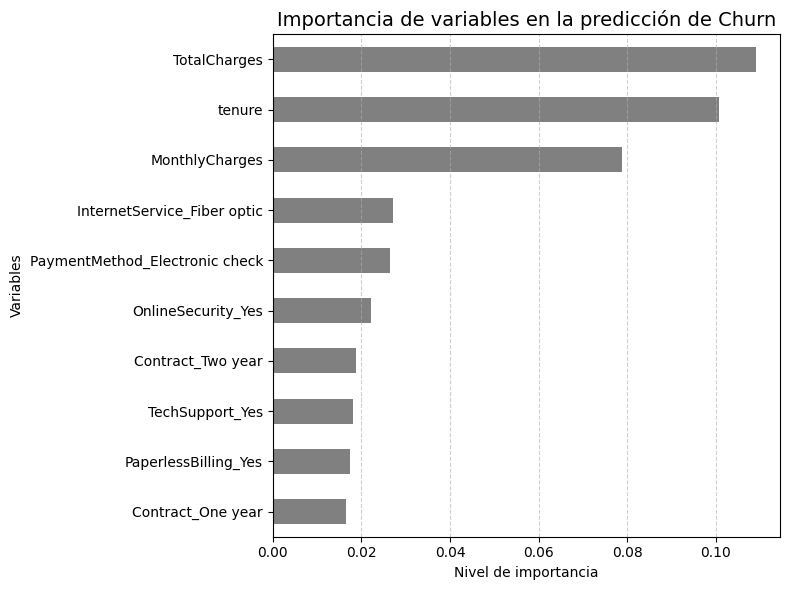

In [21]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
df_importancia.sort_values(by="Importancia", ascending=True).tail(10).plot(
    x="Variable",
    y="Importancia",
    kind="barh",
    figsize=(8,6),
    color="gray",
    legend=False
)

plt.title("Importancia de variables en la predicción de Churn",fontsize=14)
plt.xlabel("Nivel de importancia")
plt.ylabel("Variables")

plt.grid(axis="x", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

# Informe final

**Misión**

El objetivo de este proyecto fue desarrollar modelos predictivos capaces de prever qué clientes tienen mayor probabilidad de cancelar sus servicios (churn).

Para lograrlo se construyó un pipeline de análisis que incluye preparación de datos, entrenamiento de modelos de Machine Learning y evaluación de su rendimiento, con el fin de generar insights que ayuden a la empresa a reducir la cancelación de clientes.

**Preparación de los datos para el modelado**

Se utilizó el dataset de clientes de TelecomX, previamente tratado en la primera parte del desafío.

Durante el procesamiento se realizaron las siguientes tareas:



*   Eliminación o tratamiento de valores faltantes.
*   Conversación de variables categóricas en variables numéricas mediante codificación.

*   Separación de variables predictorias (X) y variable objetivo (Churn).

*   División del dataset en datos de entrenamiento y prueba.
*   Normalización de variables cuando fue necesario.

Este proceso permitió preparar los datos adecuadamente para el entrenamiento de Machine Learning.

**Análisis de correlación y selección de variables**

Se realizó un análisis exploratorio para identificar las variables que presentan mayor relación con la cancelación de clientes.

Entre las variables más relevantes se destacan:

* Tenure (tiempo como cliente)
* MonthlyCharges (cargos mensuales)
* TotalCharges (cargos totales)
* Tipo de contrato
* Servicios de internet

Estas variables muestran mayor influencia en la probabilidad de que un cliente cancele su servicio.

**Modelos de clasificación entrenados**

Se entrenaron dos modelos de clasificación para predecirla cancelación de clientes:


1.   **Regresión Logistica**

Modelo estadístico utilizado para problemas de clasificación binaria que permite estimar la probabilidad de que un cliente abandone el servicio.

2.   **Random Forest**

Modelo basado en múltiples árboles de decisión que mejora la capacidad de predicción al combinar diferentes modelos.

**Evaluación de modelos**

Los modelos fueron evaluados utilizando diferentes métricas de desempeño:

* **Accuracy**
* **Precision**
* **Recall**
* **F1-score**

Los resultados indicaron que el modelo **Random Forest** presente un rendimiento superior en la predicción de cancelación de clientes.

**Imprtancia de variables**
El análisis de importancia de variables permitió identificar los factores que más influyen en la cancelación de clientes.

Entre los factores más relevantes se encuentran:

* **Contratos mensuales (Month-to-Month)**
* **Bajo tiempo de permanencia (tenure)**
* **Altos cargos mensuales**
* Algunos **servicios adicionales de internet**

Esto sugiere que los clientes más recientes y con contratos más flexibles presentan mayor probabilidad de cancelar el servicio.


**Conclusión estratégica**

A partir del análisis realizado, se pueden proponer algunas estrategias para reducir la cancelación de clientes:

* Incentivar contratos de mayor duración con beneficios o descuentos.

* Implementar programas de fidelización para nuevos clientes.
* Revisar la estructura de precios y cargos mensuales.
* Ofrecer paquetes de servicios más atractivos que aumenten el valor percibido por los clientes.

La aplicación de modelos predictivos permite anticipar la cancelación de clientes y tomar decisiones basadas en datos , lo que puede mejorar significativamente las estrategias de retención de TelecomX.










